# KymoTracker diffusion and position analysis, with hand drawn trace initialisation

version: 01 Apr 2025 |  Benjamin Ambrose  

David Rueda lab - Single-Molecule Imaging Group at LMS MRC/Imperial College London

--------------------------------------------------------------------------------

Modified version of .ipynb from Artur Kaczmarczyk (09 November 2022) using built in pylake tracking algorithm

Features of the script:
- Genomic position analysis using bead center as a reference 
- Single-particle tracking via hand drawn trace selection and gaussian refinement
- Exports track with position in um and bp along with intensity
- Exports metadata file containing details needed to reproduce analysis

Key differences from 09 November 2022 Script:
- Traces are initialised by hand drawing rather than via peak detection, removing need to carefully tweak parameters in order to get the algorithm to recognise the molecule.
- Picked traces are then refined using built in pylake algorithm. This uses full downsampling rather than sliding window, so the MSD/tau plot is not distorted at tau = 1 and tau = 2 and data is not double counted.
- Conversion from um to bp is done using the actual bead to bead length of your lambda, rather than assuming 0.34 nm per bp. 
- Beads centers are also tracked over the time period covering the tracks you are interested in, to check for tether drift.
- Meta data with your analysis parameters is saved, as well as the initialisation scribble, so that tracks can be reproduced with a batch script if necessary (tbd)

Other notes:
- The words track and trace are used interchangeably here
- You will need to install the cv2 package to get this to work, but this can be done quite easily
- DNA length of 48501 bp (lambda) is assumed, edit if necessary

In [19]:
import lumicks.pylake as lk
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn
try: #will attempt to use catppuccin for darkmode viewing, reverts to default colors if not available
    import mplcatppuccin
    mpl.style.use("mocha")
    from mplcatppuccin.palette import load_color
except:
    'no catppuccin, using default colors'
import numpy as np
import peakutils
import matplotlib.patheffects as pe
import pandas as pd
import tkinter as tk
import PIL.Image, PIL.ImageTk
import cv2
from lumicks.pylake.kymotracker.kymotrack import KymoTrack, KymoTrackGroup
import statistics


This code will search for a kymo .h5 in the directory this notebook is in

In [20]:
filenames = os.listdir('./')  
Filenames = []
for filename in filenames:                      # select .h5 files only
    if filename[-3:] == '.h5':
        Filenames.append(filename)
if len(Filenames) > 1:
    print('Mutiple .h5 files found')
name = str(Filenames[0])                        # if there is more .h5 in the directory, change the index 0 to 1 or more
print("Imported file: " + name)
file = lk.File(name)

kymo = file.kymos[[key for key in file.kymos][0]] #this just yields the first kymo in the first file. This is probably the kymo you want

Imported file: EXAMPLEKYMO.h5


This gives an RGB picture of the whole kymo

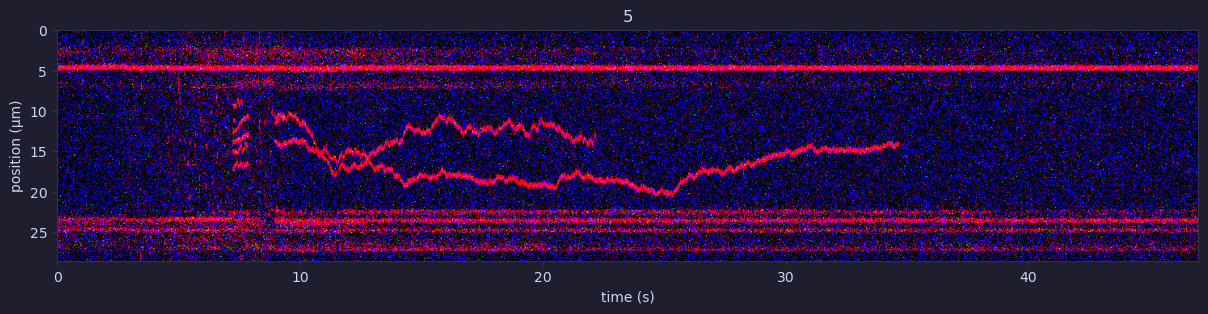

In [21]:
plt.figure(figsize=(25,3))
kymo.plot('rgb', adjustment=lk.ColorAdjustment(0,94, mode ='percentile'))
if not os.path.exists('images'):
    os.makedirs('images')
plt.savefig('images/fullkymo.png')

## Conversion to Genomic position

This section uses the red dot at the center of beads to calibrate to whole genomic position. If you don't have the red dot (or you have a different color dot) it will need to be changed.

First we will choose the times over which to take cumulative intensity (t1 and t2). If you want you can set t2 arbitrarily high and it will sum the whole data. We then fit peaks to the cumulative data. 

You should choose which color channel your bead centers appear in.
If it isn't finding the peaks of the beads, change 'threshold_bead'

Text(0, 0.5, 'Normalised Time Averaged Intensity')

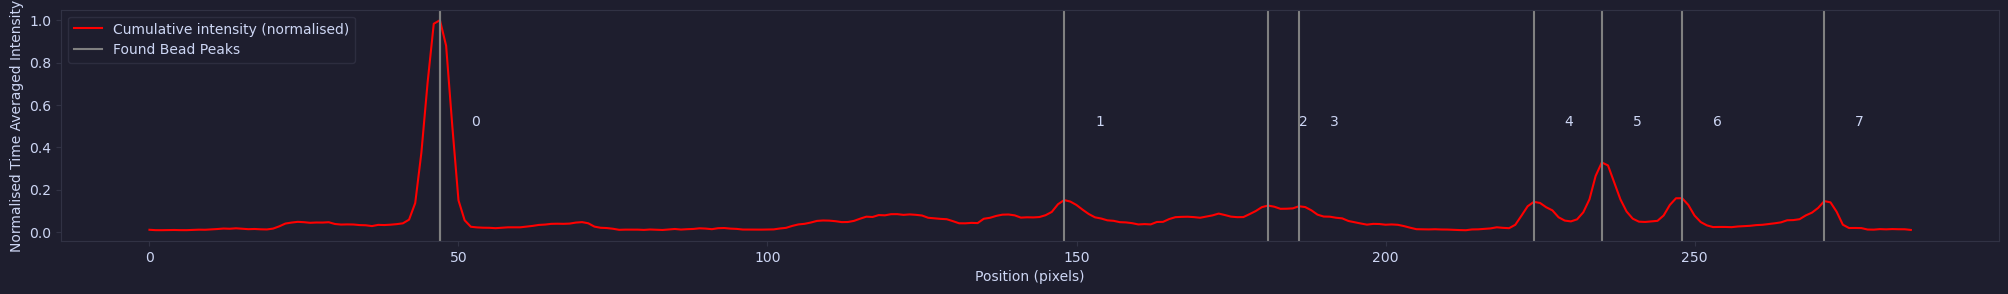

In [22]:
t1, t2 = 7, 100 #times over which to create the cumulative intensity
beadcolor = 'red' #the color you want to sum over, best to use whatever color the center of the bead comes out as
threshold_bead = 0.1
t1, t2 = round(t1/kymo.line_time_seconds), round(t2/kymo.line_time_seconds)
image = kymo.get_image(beadcolor)[:,t1:t2] #gets the image from t1 to t2
cumintensity = np.sum(image, axis=1)
normcum = cumintensity/max(cumintensity)

bead_indexes = peakutils.indexes(normcum, threshold_bead, min_dist=3)

plt.figure(figsize=(25,3))
plt.plot(normcum, color =beadcolor, label='Cumulative intensity (normalised)')
plt.axvline(bead_indexes[0], color = 'grey', label='Found Bead Peaks')
for i, bead in enumerate(bead_indexes):
    plt.axvline(bead, color = 'grey')
    plt.annotate(str(i), (bead+5, 0.5))
plt.legend()
plt.xlabel('Position (pixels)')
plt.ylabel('Normalised Time Averaged Intensity')

Here, select which of the peaks that have been found correspond to the bead centers. Unless the bead centers are very dim or your molecules are very bright, it will have only found the two bead centers in which case you should input 0 and 1.

This time select the color of your molecules, and it will display cumulative intensity in bp.

The way this works is that find the positions of the edges of the beads by adding/subtracting 1/2 bead diameter to the bead center positions. We know how far this distance is in um because we know pixel size (it is saved in the kymo) and we know that there should be 48502 bp between these two positions. Note that the interpolation done below simply creates a new x axis for the plot shown. The conversion of positions into bp is done later in the notebook, using seperate calculation, as tracked molecule positions have subpixel precision.

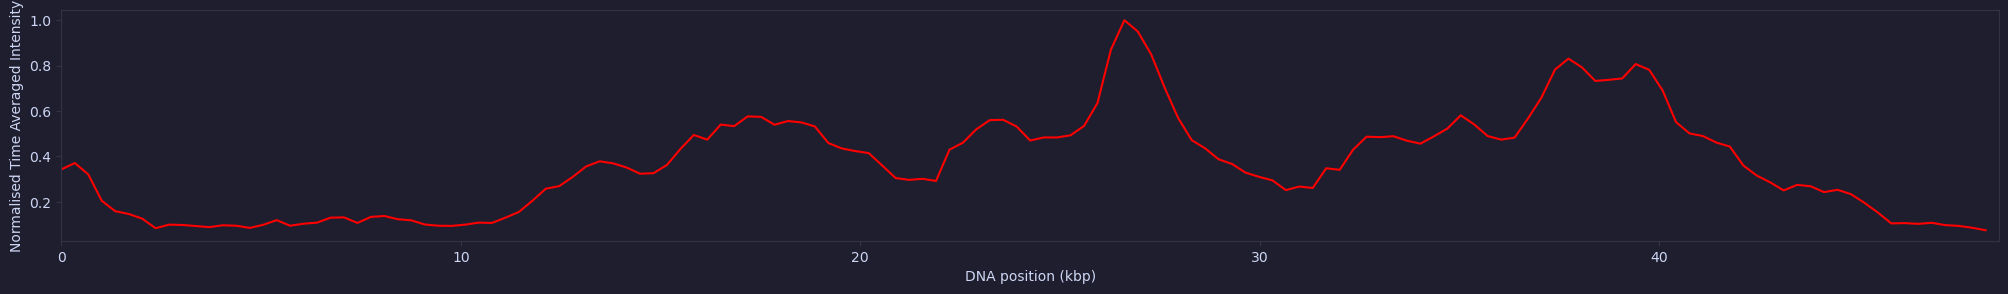

In [23]:
leftbeadpeak = 0 #the peaks corresponding to left and right beads (check the peak assignment above)
rightbeadpeak = 5


beaddiam = 4430 #bead size in nm
ps = kymo.pixelsize_um[0]*1000 #pixel size in nm

color = 'red' #color of your molecules!

roi_left, roi_right = round(bead_indexes[leftbeadpeak]+0.5*beaddiam/ps), round(bead_indexes[rightbeadpeak]-0.5*beaddiam/ps)
roi = [roi_left, roi_right]
lambdaDNA = [0, 48.502] #lambda DNA is 48.5kbp plus 2bp :)
pixlines = np.arange(roi_left, roi_right,1)
bpposition = np.interp(pixlines,roi,lambdaDNA)
t1 = 0 #time period over which to cumulate data
t2 = 4000 
image = kymo.get_image(color)[roi_left:roi_right, t1:t2] #crops using the parameters above
cumintensity = np.sum(image, axis=1)
normcum = cumintensity/max(cumintensity)
plt.figure(figsize=(25,3))
plt.plot(bpposition, normcum, color =color, label='Cumulative intensity (normalised)')
plt.xlabel('DNA position (kbp)')
plt.xlim(0,48.5)
plt.ylabel('Normalised Time Averaged Intensity')
plt.savefig('images/genomicposition.png')

## Tracking

Now we can track the molecules. We'll start by showing the whole kymo again for ease of selecting cropping numbers

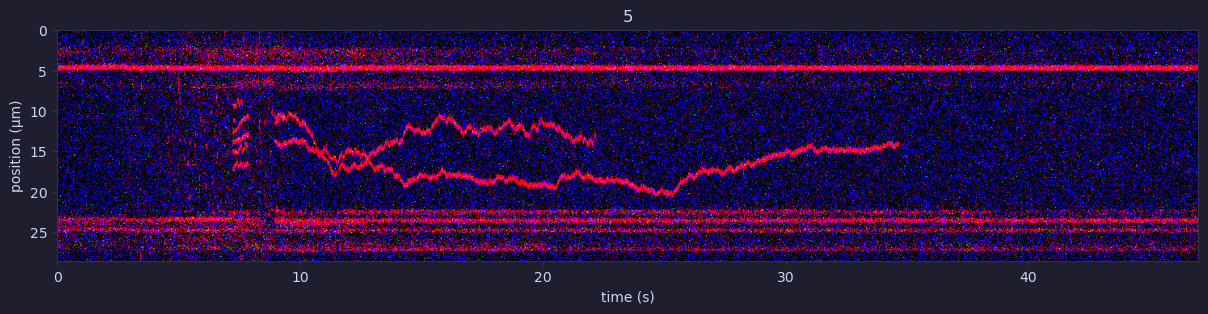

In [24]:
plt.figure(figsize=(25,3))
kymo.plot('rgb', adjustment=lk.ColorAdjustment(0,95, mode ='percentile'), cmap='afmhot')

Now choose the crop positions for the tracks you are interested in. The crop positions are in um and seconds as in the kymo above.

The time_factor variable will downsample the data in time (eg. combining every 3 frames into 1 frame). This improves signal to noise for tracking purposes, but if your signal to noise is extremely good you may be able to get away with setting this to 1.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


<Figure size 2500x300 with 0 Axes>

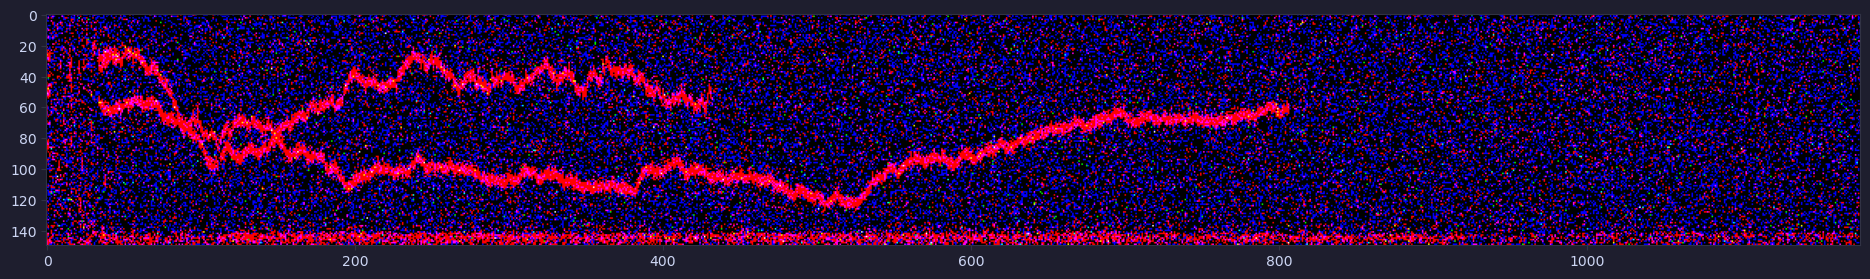

In [25]:
pos1 = 8
pos2 = 23
t1 = 8
t2 = 100

time_factor = 3

t1, t2 = str(t1)+'s', str(t2)+'s'
plt.figure(figsize=(25,3))
croppedkymo = kymo[t1:t2].crop_by_distance(pos1, pos2)
croppedkymo_ds = croppedkymo.downsampled_by(time_factor=time_factor)
image = croppedkymo.get_image('rgb')
topval = np.percentile(image.flatten(), 99.5)
image = image**(1/2)*255/topval**(1/2) #normalise to sqrt of 99.5 percentile
plt.figure(figsize=(25,3))
plt.imshow(image)
plt.savefig('images/croppedkymo.png')

Now we can select which tracks to analyse. You can put scaling factors here which will make the kymo bigger or smaller on your screen. You can then draw on the tracks in the gui. You can either hold down left click for fine control or do single clicks to draw straight lines, the refinement algorithm later on will attempt to fill in the gaps. Press D to save a trace and draw another one, or A to clear the drawing and start again. Close the gui when you are done but press D to save the trace first!

These drawings do not have to be perfect, the refinement algorithm later on will look within a window around your drawing in order to refine it. If your drawing is super imprececise you can just increase this window, but for a crowded kymo this isn't a great idea so try not to be too messy.

If you are going to move/resize the window it may be a good idea to hit [a] after just to remove any mouse clicks that may have been registered

In [9]:
scalingx = 1 #scaling factors for the kymo image
scalingy = 3

#color correction
gamma = 0.5 #adjust down to change how much the bright foci 'pop' 
red = croppedkymo.get_image('rgb')[:,:,0]
red = 255*red**gamma/max(red.flatten()**gamma)
grn = croppedkymo.get_image('rgb')[:,:,1]
grn = 255*grn**gamma/max(grn.flatten()**gamma)
blu = croppedkymo.get_image('rgb')[:,:,2]
blu = 255*blu**gamma/max(blu.flatten()**gamma)
rgb = np.dstack((red,grn,blu))

bigimage = cv2.resize(rgb, (0,0), fx=scalingx, fy = scalingy).astype(np.uint8) #I called this bigimage, but it could theoretically be smaller if the scaling factors <1
height, width, ncolours = np.shape(bigimage)
drawn_x_coordinates = set()
drawn_positions = []
saved_traces = []
def draw(event): #handles drawing of new lines
    x, y = event.x, event.y
    if y > 0: #only draws if in frame. Allows you to move the window without drawing
        if drawn_positions:
            x0,y0 = drawn_positions[-1]
            canvas.create_line(x0, y0, x, y, fill='white', width = 2, tags = ['currentscribble'])
        if x not in drawn_x_coordinates:
            drawn_x_coordinates.add(x)
            drawn_positions.append((x,y))
            canvas.create_oval(x-1, y-1, x+1, y+1, fill='white', tags = ['currentscribble'])
def clear(event): #handles the clearing of drawn lines
    global drawn_positions
    global drawn_x_coordinates
    canvas.delete('currentscribble')
    drawn_positions = []
    drawn_x_coordinates = set()
def save(event): #this moves the drawn track from drawn_positions into saved_traces, then clears drawn_positions ready for the next trace
    global drawn_positions
    global drawn_x_coordinates
    x0, y0 = drawn_positions[0]
    for xy in drawn_positions: #redraws the lines in magenta
        x, y = xy
        canvas.create_line(x0, y0, x, y, fill='magenta', width = 2)
        x0, y0, = x, y
    canvas.delete('currentscribble') #removes the lines already drawn in the active color
    saved_traces.append(drawn_positions)
    drawn_positions = []
    drawn_x_coordinates = set()
root = tk.Tk()
canvas = tk.Canvas(root, width=width, height=height+50)
canvas.pack()
photo = PIL.ImageTk.PhotoImage(image = PIL.Image.fromarray(bigimage))
canvas.create_image(0, 0, image=photo, anchor='nw', )
canvas.create_text(150,height+25, text='[a] to delete scribble, [d] to save scribble', fill='white')
root.bind('<B1-Motion>', draw)
root.bind('<Button-1>', draw)
root.bind('d', save)
root.bind('a', clear)
root.mainloop()

2025-04-01 15:16:53.269 python[63587:773667] +[IMKClient subclass]: chose IMKClient_Modern
2025-04-01 15:16:53.269 python[63587:773667] +[IMKInputSession subclass]: chose IMKInputSession_Modern


This will show the tracks you drew, with numbers on, so you can check that it came out okay.

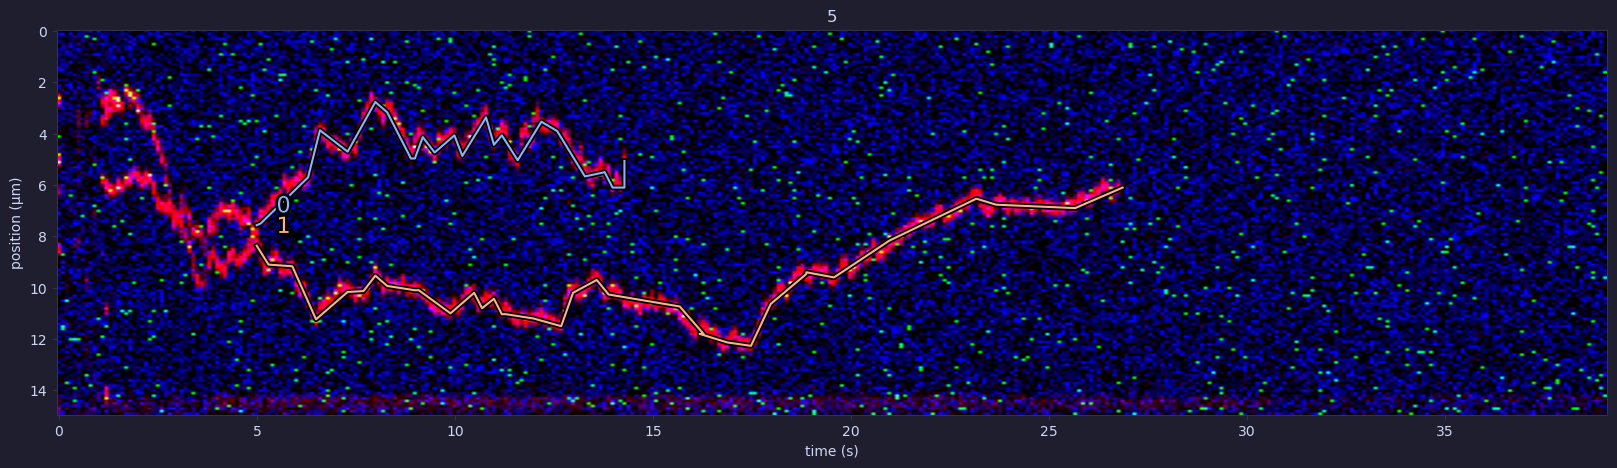

In [26]:
channel = color
#spoofing the tracks as if they were og pylake objects
tracks = []
for trace in saved_traces:
    cleanedtrace = [x for x in trace if x[1] > 0] #removes mouseclicks above the frame (from repositioning etc.)
    times = [int(x[0]/(scalingx*time_factor)) for x in cleanedtrace] #correct for time factor
    positions = [x[1]/scalingy for x in cleanedtrace]
    track = KymoTrack(time_idx = times, localization = positions, kymo = croppedkymo_ds, channel = channel, minimum_observable_duration=None)
    tracks.append(track)
tracks = KymoTrackGroup(tracks)
plt.figure(figsize=(20,5))
croppedkymo_ds.plot(channel='rgb', aspect = 'auto', adjustment=lk.ColorAdjustment(0, 98, mode="percentile"), cmap='afmhot')
for i, track in enumerate(tracks):
    t, pos = track.seconds, track.position
    g = plt.plot(t, pos, linewidth = 1.5, path_effects=[pe.withStroke(linewidth=4, foreground="black")]) #the path effect here drops a black shadow for visibility
    plt.annotate(i, (t[0]+0.5, pos[0]-0.5), fontsize=16, color=g[0].get_color(), path_effects=[pe.withStroke(linewidth=4, foreground="black")])
plt.savefig('images/trackedkymo.png')

Now we can refine the tracks by fitting a gaussian peak in a window around the hand drawn track. Note that 'gaussianrefinementwindow' refers to the number of pixels either side of the greedy track. So the actual size of the window that is checked is 2N+1

overlap_strategy='simultaneous' allows it to refine all traces in the group at the same time, so if they come close to each other they will not be confused/combined.

In [27]:
gaussianrefinementwindow = 5
refinedtracks = lk.refine_tracks_gaussian(tracks, window = gaussianrefinementwindow, refine_missing_frames=True, overlap_strategy='simultaneous')

This will display the hand drawn tracks and the refined tracks

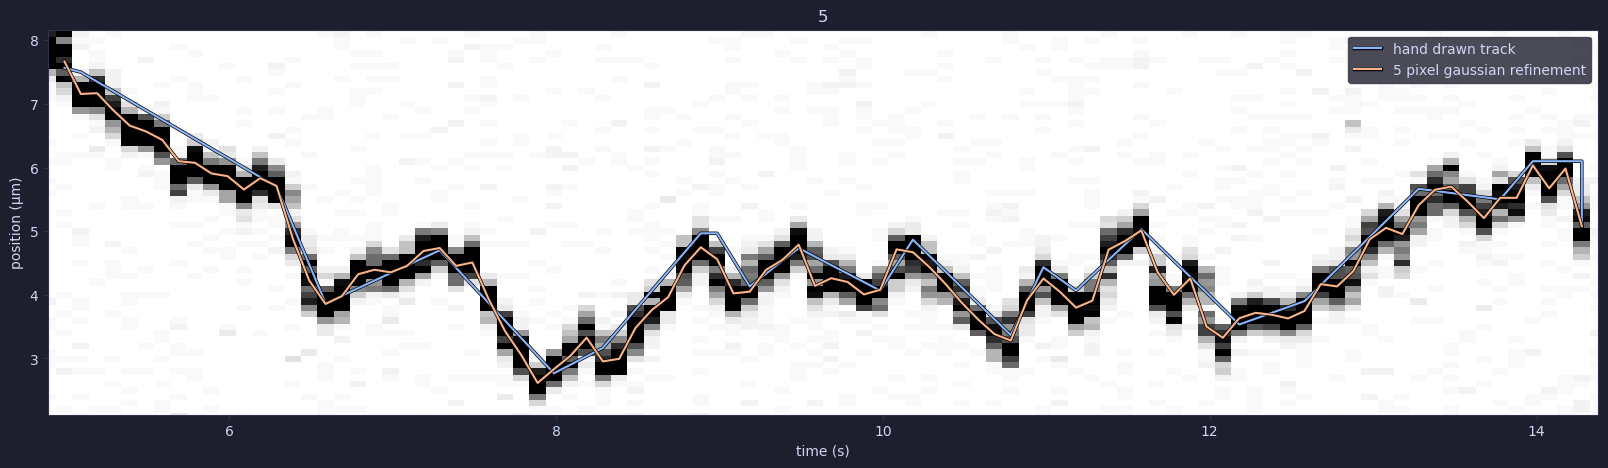

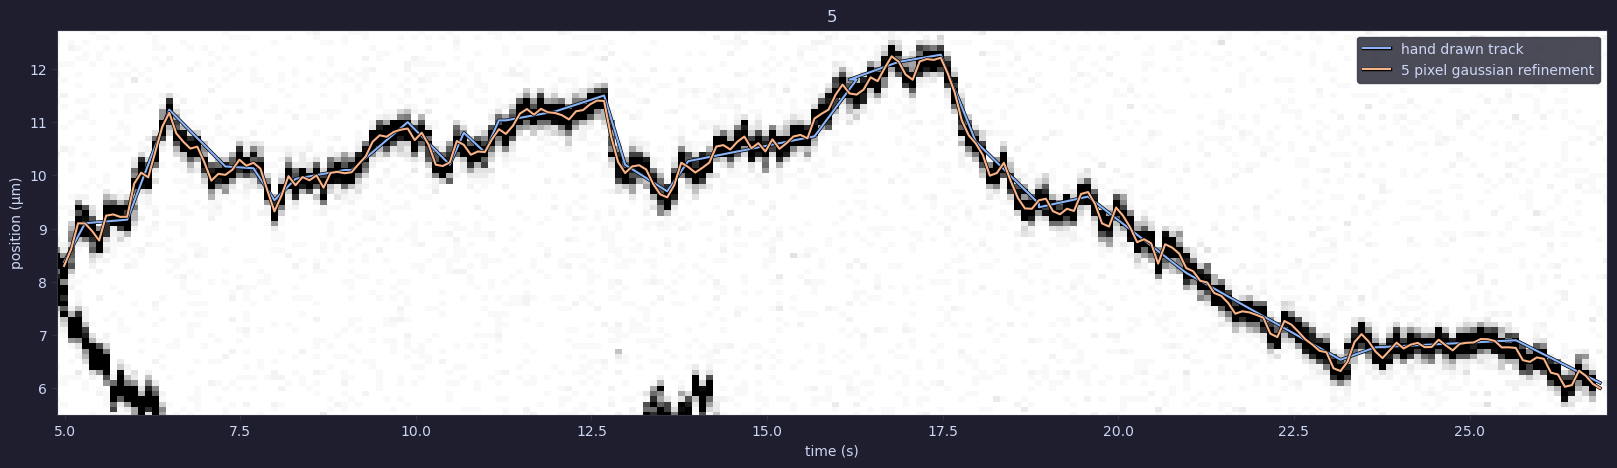

In [28]:
for i, track in enumerate(tracks):
    refined = refinedtracks[i]
    plt.figure(figsize=(20,5))
    croppedkymo_ds.plot(channel=color, aspect = 'auto', adjustment=lk.ColorAdjustment(0, 98, mode="percentile"), cmap='Greys', zorder=1)
    plt.plot(track.seconds, track.position,linewidth=1.5, label='hand drawn track', path_effects=[pe.withStroke(linewidth=2.5, foreground="black")])
    plt.plot(refined.seconds, refined.position, linewidth = 1.5, label=str(gaussianrefinementwindow)+ ' pixel gaussian refinement',  path_effects=[pe.withStroke(linewidth=2.5, foreground="black")])
    plt.xlim(min(refined.seconds)-0.1,max(refined.seconds)+0.1)
    plt.ylim(min(refined.position)-.5,max(refined.position)+.5)
    plt.legend()
    plt.savefig('images/trace'+str(i)+'tracks.png')

This will plot the intensities of your selected traces

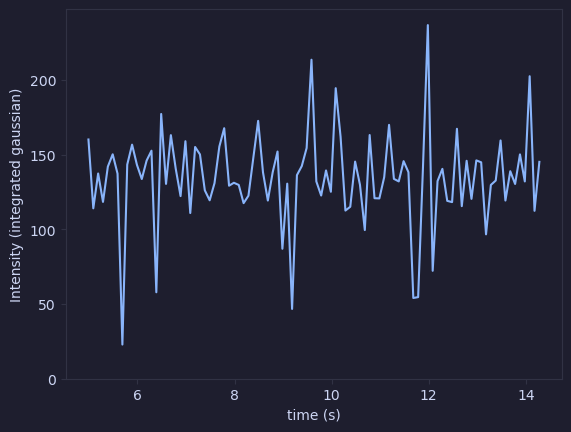

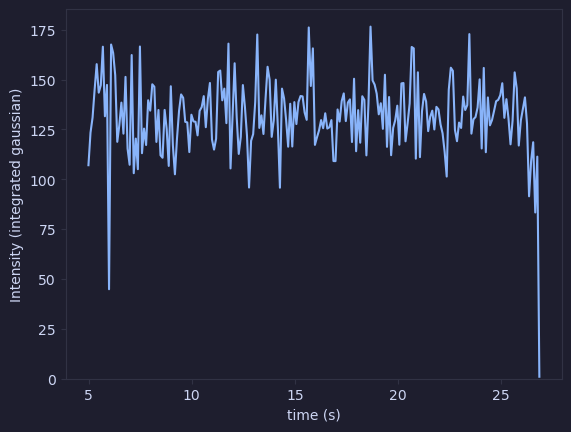

<Figure size 640x480 with 0 Axes>

In [29]:
for i, track in enumerate(refinedtracks):
    plt.plot(track.seconds, track.photon_counts)
    plt.ylim(0,)
    plt.xlabel('time (s)')
    plt.ylabel('Intensity (integrated gaussian)')
    plt.show()
    plt.savefig('images/trace'+str(i)+'intensity.png')
    

## Exporting the data
First we work out the transformation details for getting from um into bp space (bearing in mind that we have cropped the kymo)

Then we export both the data and a meta data file with all the tracking information, as well as the trace initialisation drawings

In [30]:
bpperpix = 48502 / (pixlines[-1] - pixlines[0]) #these parameters are for converting from the position in microns to bp
bperum = bpperpix / kymo.pixelsize_um[0] #note that bp per um is NOT necessarily 2941, because the DNA is under tension
beadcrop = roi_left * kymo.pixelsize_um[0]
umfromstart = pos1 - beadcrop #to work out how far our zero is from the actual zerobp, we take our crop pos1 and subtract the position of the edge of the bead

if not os.path.exists('traces'):
    os.makedirs('traces')
if not os.path.exists('trace_metadata'):
    os.makedirs('trace_metadata')
if not os.path.exists('initialisation_scribbles'):
    os.makedirs('initialisation_scribbles')
for i, track in enumerate(refinedtracks):
    tracename = name[:-3]+'_trace'+str(i)
    time = track.seconds
    posinum = [x+umfromstart for x in track.position] #here we add the um from start to get genomic position in um
    posinbp = [round(x*bperum) for x in posinum] #then multiply by the factor from above to convert to bp
    intensity = track.photon_counts
    df = pd.DataFrame({'time (s)':time, 'position (um)':posinum, 'position (bp)':posinbp, 'intensity': intensity})
    df.to_csv('traces' +'/'+ tracename+'.csv', index=False)
    metadict = {'kymo filename':name,'timecrop1' : t1,'timecrop2' : t2,'poscrop1' : pos1,'poscrop2' : pos2, 'gaussianrefinementwindow': gaussianrefinementwindow}
    metaframe = pd.DataFrame(metadict,  index=[0]).transpose()
    metaframe.to_csv('trace_metadata'+'/'+tracename+'metadata.csv', header=False)
    scribble = pd.DataFrame({'time (s)': tracks[i].seconds, 'position (um)': tracks[i].position})
    scribble.to_csv('initialisation_scribbles'+'/'+tracename+'initialisation.csv', index=False)

## Tracking the bead

Additionally we can attempt to track both beads in order to get traces for known non diffusors. This can act as a good control, as things which aren't diffusing at all may not necessarily come out with a nonzero diffusion coefficient. It can also be used simply to check that the beads did not move significantly over the course of the tracks you are interested in. For this reason it is run specifically over the time period covering all of your tracks

This actually works by pulling out the peak that was found earlier up the notebook and drawing a straight line at that position, then running a gaussian refinement on the straight line.

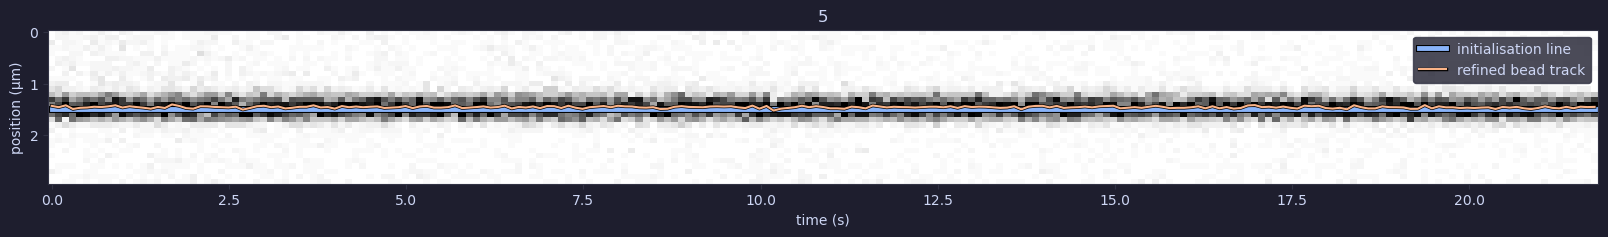

In [50]:
trackstart = str(min([x[0] for x in [x.seconds for x in tracks]])+int(t1[:-1]))+'s' #finds earliest time point in the tracks you selected within the cropped kymo then adds t1 back on to get back into uncropped space
tracksend = str(max((x[-1] for x in [x.seconds for x in tracks]))+int(t1[:-1]))+'s' #same but for last time point
leftbeadum = bead_indexes[leftbeadpeak]*kymo.pixelsize_um[0]
leftbead = kymo[trackstart:tracksend].crop_by_distance(leftbeadum-1.5, leftbeadum+1.5)
leftbead = leftbead.downsampled_by(time_factor=time_factor)
tracklength = leftbead.duration/leftbead.line_time_seconds-1
lefttrackline = KymoTrackGroup([KymoTrack(time_idx = [0, int(tracklength)], localization = [15,15], kymo = leftbead, channel = channel, minimum_observable_duration=None)])
lefttrack = lk.refine_tracks_gaussian(lefttrackline, window = 6, refine_missing_frames=True, overlap_strategy='simultaneous')
plt.figure(figsize=(20,2))
leftbead.plot(channel=beadcolor, aspect = 'auto', adjustment=lk.ColorAdjustment(0, 98, mode="percentile"), cmap='Greys')
plt.plot(lefttrackline[0].seconds, lefttrackline[0].position, linewidth = 3.5, path_effects=[pe.withStroke(linewidth=5, foreground="black")], label =  'initialisation line')
plt.plot(lefttrack[0].seconds, lefttrack[0].position, linewidth = 1.5, path_effects=[pe.withStroke(linewidth=2.5, foreground="black")], label = 'refined bead track')
plt.legend()
plt.savefig('images/leftbead.png')

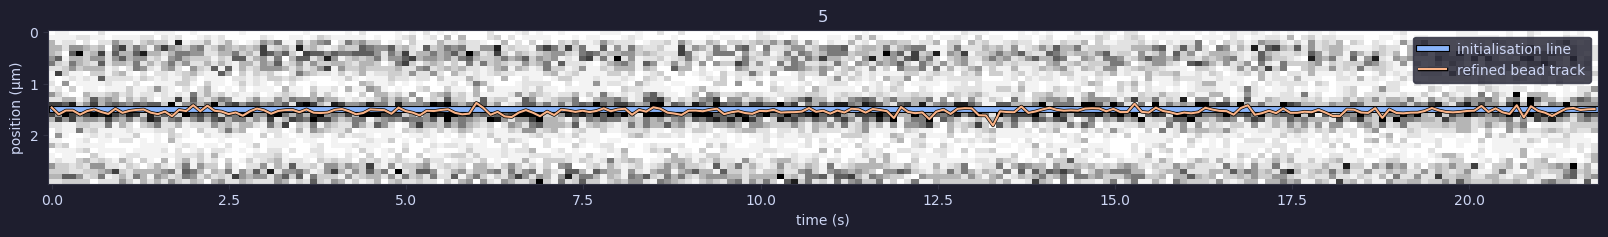

In [51]:
rightbeadum = bead_indexes[rightbeadpeak]*kymo.pixelsize_um[0]
rightbead = kymo[trackstart:tracksend].crop_by_distance(rightbeadum-1.5, rightbeadum+1.5)
rightbead = rightbead.downsampled_by(time_factor=time_factor)
tracklength = rightbead.duration/rightbead.line_time_seconds-1
righttrackline = KymoTrackGroup([KymoTrack(time_idx = [0, int(tracklength)], localization = [15,15], kymo = rightbead, channel = channel, minimum_observable_duration=None)])
righttrack = lk.refine_tracks_gaussian(righttrackline, window = 6, refine_missing_frames=True, overlap_strategy='simultaneous')
plt.figure(figsize=(20,2))
rightbead.plot(channel=beadcolor, aspect = 'auto', adjustment=lk.ColorAdjustment(0, 98, mode="percentile"), cmap='Greys')
plt.plot(righttrackline[0].seconds, righttrackline[0].position, linewidth = 3.5, path_effects=[pe.withStroke(linewidth=5, foreground="black")], label =  'initialisation line')
plt.plot(righttrack[0].seconds, righttrack[0].position, linewidth = 1.5, path_effects=[pe.withStroke(linewidth=2.5, foreground="black")], label = 'refined bead track')
plt.legend()
plt.savefig('images/rightbead.png')

Now we can export this data

In [33]:
if not os.path.exists('beadtraces'):
    os.makedirs('beadtraces')
leftbeadtrace, rightbeadtrace = lefttrack[0], righttrack[0]
leftdf = pd.DataFrame({'time (s)':leftbeadtrace.seconds, 'position (um)':leftbeadtrace.position, 'position (bp)':[round(x*bperum) for x in leftbeadtrace.position], 'intensity': leftbeadtrace.photon_counts})
rightdf = pd.DataFrame({'time (s)':rightbeadtrace.seconds, 'position (um)':rightbeadtrace.position, 'position (bp)':[round(x*bperum) for x in rightbeadtrace.position], 'intensity': rightbeadtrace.photon_counts})
leftdf.to_csv('beadtraces'+'/'+name[:-3]+'leftbead.csv', index=False)
rightdf.to_csv('beadtraces'+'/'+name[:-3]+'rightbead.csv', index=False)

## Calculating Diffusion by MSD/Tau

Now we can calculate diffusion coefficient

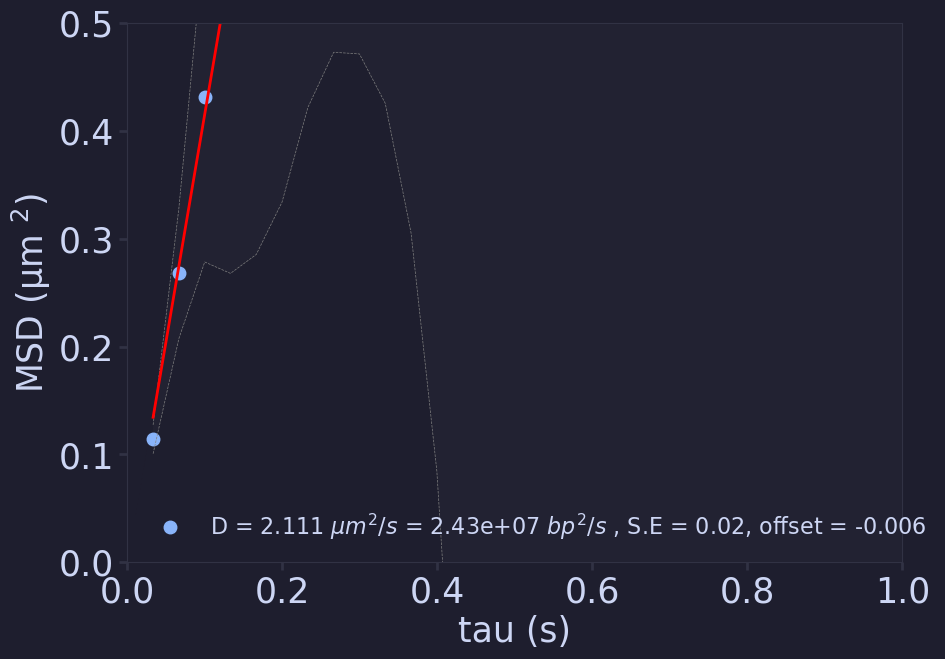

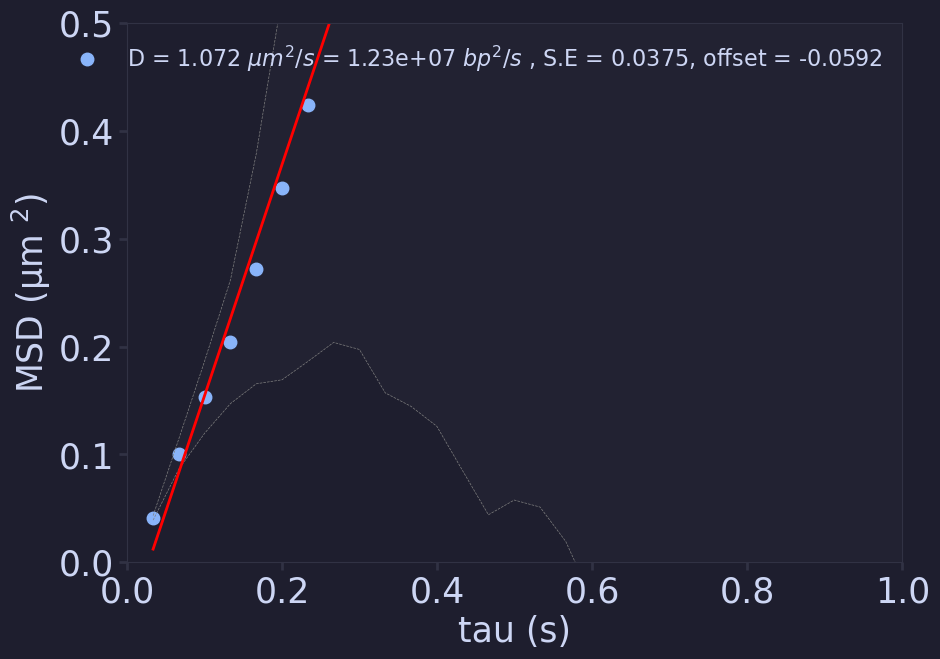

In [34]:
for track in refinedtracks:
    pos = track.position
    line_time = kymo.line_time_seconds
    window_min = 0
    window_max = 10

    N = len(pos)  # number of time frames (kymograph lines)
    SqD, MSD, MSD_local, tau, var_array, var_up, var_down = [],[],[],[],[],[],[]

    for n in range (1,N-3):        # probing different window sizes starting from n =1 (single linetime - dt) until N-1 (N-3 to be able to calculate variance of the last points)    
        tau = np.append(tau,[n*line_time],axis=0)
        SqD = []    
        for i in range (1,N-n):  # for each time window calculate square displacements between i and i+n frame        
            SqD = np.append(SqD,[(pos[i+n]-pos[i])**2],axis=0)
        MSD_point = np.sum(SqD)/(N-n)
        var = statistics.variance(SqD[:])    
        MSD = np.append(MSD,[np.sum(SqD)/(N-n)],axis=0)   # calculate mean square displacement for each window size
        var_array = np.append(var_array,[var],axis=0)
        var_up = np.append(var_up,[MSD_point+ 0.5*var],axis=0)
        var_down = np.append(var_down,[MSD_point- 0.5*var],axis=0)
    param,cov = np.polyfit(tau[window_min:window_max], MSD[window_min:window_max], 1,cov=True)
    y = param[0]*tau + param[1]
    #Standard error of the linear regression
    covMSD = (np.sqrt(np.diag(cov)))
    bp_um = (param[0]/2)*(bperum)**2  
    # Plot MSD  #plot only 150x linetime, not the whole range (Still the whole range is saved)
    fig, ax = plt.subplots(figsize=(10, 7)) 
    ax.plot(tau,MSD,'o',markersize='9')
    ax.plot(tau[0:150],var_up[0:150],'--',color='grey',linewidth=0.5)
    ax.plot(tau[0:150],var_down[0:150],'--',color='grey',linewidth=0.5)
    plt.fill_between(tau[0:150], var_down[0:150], var_up[0:150], facecolor="grey", alpha=0.05)
    ax.plot(tau,y,'r',linewidth=1)
    ax.plot(tau[window_min:window_max],y[window_min:window_max],'r',linewidth=2)
    ax.tick_params(direction='out', length=6, width=2, labelsize= 25, grid_color='r', grid_alpha=0.5)
    ax.set_xlabel("tau (s)", fontsize=25)
    ax.set_ylabel("MSD (\u03BCm $^{2}$)", fontsize=25)
    '''CHOOSE AXIS RANGE TO VISUALIZE MSD'''
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 0.5])

    ax.legend(['D = ' + str(np.around(param[0]/2,decimals =3))+' $\u03BCm^2/s$ = ' + "{:0.2e}".format(bp_um) + " $bp^2/s$" + " , S.E = " + str(np.around(covMSD[0]/2,decimals =4)) + ", offset = "+ str(np.around(param[1],decimals=4))],fontsize=16, frameon=False)
    plt.savefig('images/trace'+str(i)+'MSDtau.png')